<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_12_2_feature_importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks
**Module 12: Explainability**  

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 12 Material

* Part 12.1: What is Explainability [[Video]]() [[Notebook]](t81_558_class_12_1_explainability.ipynb)
* **Part 12.2: Feature Importance** [[Video]]() [[Notebook]](t81_558_class_12_2_feature_importance.ipynb)
* Part 12.3: Visualization for Computer Vision [[Video]]() [[Notebook]](t81_558_class_12_3_vision_viz.ipynb)
* Part 12.4: Gradient-Based Explanations [[Video]]() [[Notebook]](t81_558_class_12_4_gradient_explain.ipynb)
* Part 12.5: Limitations of Explainability [[Video]]() [[Notebook]](t81_558_class_12_5_limitations.ipynb)

# Google CoLab Instructions

The following code checks that Google CoLab is running and sets up the correct hardware settings for PyTorch.

In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

# Make use of a GPU or MPS (Apple) if one is available.  (see module 2.5)
import torch
has_mps = torch.backends.mps.is_built()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Note: not using Google CoLab


Using device: mps


# Part 12.2: Feature Importance

When a model is a black box, one of the most useful questions we can still answer is: which input features does it rely on? A ranking of features by importance is a *global* explanation, describing the model's behavior across the whole dataset rather than for a single prediction. It tells us whether the model is using the features we expect, exposes features that contribute nothing, and can reveal that a model is leaning on something it should not, a subtle form of data leakage or bias.

The challenge is that a neural network gives us no direct measure of importance the way a linear model's weights do. A weight deep inside the network says nothing about how much a given input feature matters to the final output. We need a method that treats the model as a function we can only query, feeding it inputs and observing outputs, and infers importance from how the outputs change. This is the model-agnostic approach, and its most popular representative is **permutation feature importance**.

This section explains the idea behind permutation importance, implements it from scratch against the black-box network from the previous section, and cross-checks the result against the glass-box model's weights. When two very different methods agree on which features matter, our confidence in both increases.

## The Idea Behind Permutation Importance

Permutation importance measures how much a model depends on a feature by *breaking* that feature and watching performance fall. The procedure is simple. First, measure the model's accuracy on a held-out set. Then pick one feature and randomly shuffle its values across all the samples, which destroys any relationship between that feature and the target while leaving every other feature untouched. Measure accuracy again. If the feature was important, scrambling it should hurt accuracy noticeably; if the model barely used it, accuracy will hardly move. The drop in accuracy is the feature's importance score.

Shuffling, rather than deleting, the feature is a deliberate choice with two advantages. It keeps the feature's own distribution intact, so the model still receives plausible-looking values rather than zeros or blanks it never saw in training. And crucially, it requires no retraining: the same trained model is queried again and again, which makes the method fast and applicable to any model, including one you did not build. Because a single shuffle is random, we repeat it several times per feature and average the drops to get a stable estimate.

## Implementing Permutation Importance

The implementation below works directly on the trained PyTorch network. The `accuracy` helper runs a forward pass and compares predictions to the true labels. The `permutation_importance` function establishes the baseline accuracy, then for each feature makes several copies of the data with that one column shuffled, measures the average accuracy drop, and records it. Everything happens under `torch.no_grad()` because we only need forward passes, never gradients.

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(0)
np.random.seed(0)

# Same dataset and black-box model as the previous section.
data = load_breast_cancer()
feature_names = data.feature_names
X_tr, X_te, y_tr, y_te = train_test_split(
    data.data, data.target, test_size=0.3, random_state=0, stratify=data.target)
scaler = StandardScaler().fit(X_tr)
X_tr_t = torch.tensor(scaler.transform(X_tr), dtype=torch.float32)
X_te_t = torch.tensor(scaler.transform(X_te), dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
y_te_t = torch.tensor(y_te, dtype=torch.float32).unsqueeze(1)

model = nn.Sequential(
    nn.Linear(30, 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 1),
)
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.BCEWithLogitsLoss()
for _ in range(300):
    opt.zero_grad()
    loss_fn(model(X_tr_t), y_tr_t).backward()
    opt.step()


def accuracy(X):
    with torch.no_grad():
        pred = (torch.sigmoid(model(X)) >= 0.5).float()
    return (pred == y_te_t).float().mean().item()


def permutation_importance(X, n_repeats=20):
    baseline = accuracy(X)
    importances = np.zeros(X.shape[1])
    for j in range(X.shape[1]):
        drops = []
        for _ in range(n_repeats):
            X_perm = X.clone()
            X_perm[:, j] = X[torch.randperm(X.shape[0]), j]   # shuffle feature j
            drops.append(baseline - accuracy(X_perm))
        importances[j] = np.mean(drops)
    return importances, baseline


importances, baseline = permutation_importance(X_te_t)
print(f"Baseline accuracy: {baseline:.3f}\n")

order = np.argsort(importances)[::-1]
print("Top 8 features by permutation importance:")
for i in order[:8]:
    print(f"  {feature_names[i]:26s} {importances[i]:+.4f}")

Baseline accuracy: 0.959

Top 8 features by permutation importance:
  worst texture              +0.0158
  worst smoothness           +0.0132
  mean concave points        +0.0123
  mean texture               +0.0120
  worst perimeter            +0.0114
  radius error               +0.0111
  worst radius               +0.0111
  mean concavity             +0.0102


The printed ranking shows a handful of features whose scrambling costs the model real accuracy, while most features barely register, meaning the network's decisions hinge on a small subset of the thirty measurements. Plotting the full set of scores makes the concentration of importance visible at a glance.

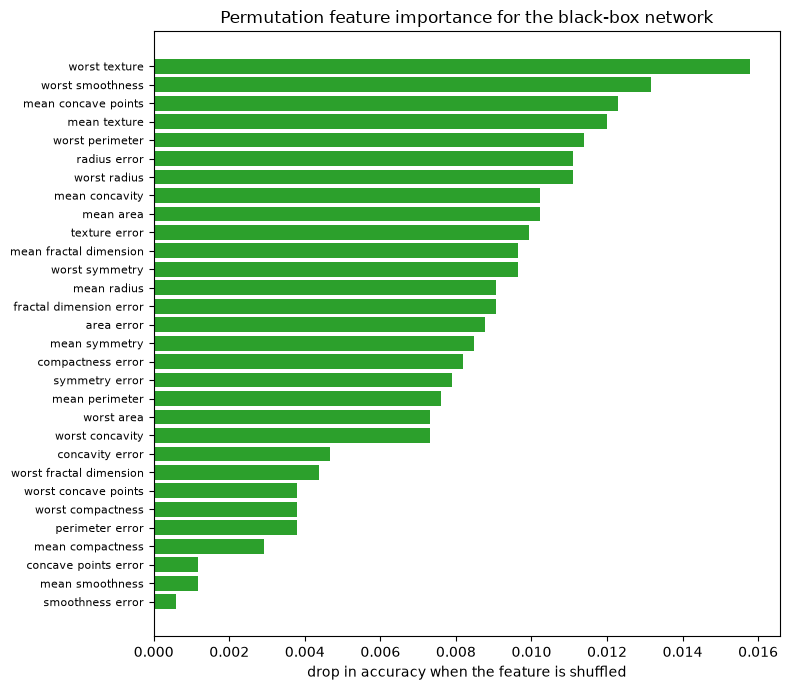

In [3]:
order = np.argsort(importances)

plt.figure(figsize=(8, 7))
plt.barh(range(30), importances[order], color="tab:green")
plt.yticks(range(30), [feature_names[i] for i in order], fontsize=8)
plt.xlabel("drop in accuracy when the feature is shuffled")
plt.title("Permutation feature importance for the black-box network")
plt.tight_layout()
plt.show()

The bar chart concentrates importance in a few features at the top, with the long tail contributing almost nothing to the model's accuracy. Both this ranking and the glass-box weights from the previous section point to the same broad *families* of measurements, the size, texture, and concavity of the cell nuclei, which is encouraging: two very different methods agree on the kinds of features that carry the signal. Their exact orderings differ, though, because many of these measurements are strongly correlated with one another, a nucleus's radius, perimeter, and area all move together, so each method can assign the shared credit differently. That mismatch is a preview of a genuine limitation we return to at the end of the module.

Permutation importance is powerful and general, but it has an important blind spot. When two features are strongly correlated, shuffling one of them does less harm than its true importance warrants, because the model can recover much of the same information from its correlated partner. Each feature can then look less important than the signal the pair jointly carries. This failure, and other ways explanations can mislead, is the subject of [Limitations of Explainability](t81_558_class_12_5_limitations.ipynb) later in this module. First, though, we turn from tabular models to images, where explanation takes on a vivid visual form. The next section is [Visualization for Computer Vision](t81_558_class_12_3_vision_viz.ipynb).